# DIAYN Skills vs Curriculum PPO — Comparison

**Goal**: evaluate whether unsupervised skill pre-training (DIAYN) accelerates downstream task learning compared to Curriculum PPO.

## Design

| | DIAYN fine-tune | Curriculum PPO baseline |
|---|---|---|
| **Starting weights** | DIAYN actor (skills 0/1/2) — transferred via input-layer projection | `checkpoints_curriculum/!final_model.pth` — already trained, just evaluated |
| **Reward** | `reward_dense` from `curriculum_ppo.ipynb` — same signal as curriculum stage 5-6 | same |
| **Fine-tune method** | PPO from the pre-trained actor | — (no retraining needed) |

**How DIAYN saves**: one file `diayn_ep{N}.pth` containing `actor`, `q1`, `q2`, `discriminator`.  
All skills share the same networks — the skill identity `z` is part of the input, not a separate model.  
We extract the `actor` weights and strip the `z` one-hot columns from the first layer before fine-tuning.

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import sys, os, math, random, time
sys.path.append(os.path.abspath('..'))

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import src.env  # registers RugbyHRLGame1-v0

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ENV_NAME  = "RugbyHRLGame1-v0"
N_SKILLS  = 3

_env      = gym.make(ENV_NAME)
OBS_DIM   = _env.observation_space.shape[0]   # 21
N_ACTIONS = _env.action_space.n               # 6
_env.close()

DIAYN_CKPT_DIR    = "checkpoints/diayn"
DIAYN_EPISODE     = 1500
CURRICULUM_CKPT   = "checkpoints_curriculum/!final_model.pth"
FINETUNE_DIR      = "checkpoints/compare"
os.makedirs(FINETUNE_DIR, exist_ok=True)

print(f"Device: {DEVICE}  obs={OBS_DIM}  actions={N_ACTIONS}  skills={N_SKILLS}")

Device: cpu  obs=21  actions=6  skills=3


/home/wboussella/Documents/RugbyHRL/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


## Reward Function

We reuse `reward_dense` from `curriculum_ppo.ipynb` so that fine-tuned DIAYN skills and Curriculum PPO are evaluated under **identical reward signals**.

In [ ]:
import math as _math

def reward_dense(result, game_map, cfg, state):
    """Dense shaping — identical to curriculum_ppo Stage 5/6."""
    if result.get("won"):  return +100.0
    if result.get("lost"): return -100.0
    p, b, g = game_map.player, game_map.ball, game_map.goal
    if p is None or b is None: return 0.0
    W, H = float(cfg.map.width), float(cfg.map.height)
    md   = _math.sqrt(W**2 + H**2)
    r    = 0.01
    if not p.has_ball:
        dist = _math.sqrt((p.pos.x-b.pos.x)**2 + (p.pos.y-b.pos.y)**2)
        r   += 0.05 * (1.0 - dist/md)
        prev = state.get("prev_dist_to_ball")
        if prev is not None: r += 0.5*(prev-dist)/md
        state["prev_dist_to_ball"] = dist
        state["prev_dist_to_goal"] = None
    else:
        if not state.get("has_picked_up_ball"):
            r += 5.0; state["has_picked_up_ball"] = True
        gcx = g.pos.x+g.width/2; gcy = g.pos.y+g.height/2
        dist = _math.sqrt((p.pos.x-gcx)**2+(p.pos.y-gcy)**2)
        r   += 0.05*(1.0-dist/md)
        prev = state.get("prev_dist_to_goal")
        if prev is not None: r += 0.5*(prev-dist)/md
        state["prev_dist_to_goal"] = dist
        state["prev_dist_to_ball"] = None
    return r


class DenseRewardEnv(gym.Wrapper):
    """
    Wraps the registered RugbyHRLGame1-v0 env, replacing its reward with
    reward_dense.  Uses the env's own engine/map — no reimplementation needed.
    """
    def __init__(self):
        env = gym.make(ENV_NAME)
        super().__init__(env)
        self._state = {}

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._state = {"prev_dist_to_ball": None,
                       "prev_dist_to_goal": None,
                       "has_picked_up_ball": False}
        return obs, info

    def step(self, action):
        obs, _orig_reward, terminated, truncated, info = self.env.step(action)
        # Access map & config through the unwrapped engine
        uw  = self.env.unwrapped
        try:
            r = reward_dense(info, uw.game_map, uw.cfg, self._state)
        except Exception:
            r = _orig_reward   # fallback: use env reward if internals differ
        return obs, r, terminated, truncated, info


# smoke test — if this crashes, ENV_NAME registration is broken
try:
    _e = DenseRewardEnv(); o,_ = _e.reset(); _e.close()
    print(f"DenseRewardEnv ok — obs shape: {o.shape}")
except Exception as exc:
    print(f"⚠  DenseRewardEnv failed ({exc}), falling back to plain gym.make")
    class DenseRewardEnv(gym.Wrapper):
        """Fallback: plain env with original reward."""
        def __init__(self):
            super().__init__(gym.make(ENV_NAME))

DenseRewardEnv ok — obs shape: (21,)


## PPO Fine-Tuner

Accepts an optional warm-start actor from DIAYN.  
Only the actor is transferred — the critic is always fresh.

In [3]:
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.orthogonal_(m.weight, gain=math.sqrt(2))
        nn.init.zeros_(m.bias)

class Actor(nn.Module):
    def __init__(self, n_states, n_actions, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_states, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),   nn.Tanh(),
            nn.Linear(hidden, n_actions),
        )
        self.apply(init_weights)
    def forward(self, x): return self.net(x)
    def get_action(self, x):
        d = Categorical(logits=self.forward(x))
        a = d.sample()
        return a, d.log_prob(a), d.entropy()

class Critic(nn.Module):
    def __init__(self, n_states, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_states, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),   nn.Tanh(),
            nn.Linear(hidden, 1),
        )
        self.apply(init_weights)
    def forward(self, x): return self.net(x).squeeze(-1)


class PPOFineTuner:
    """PPO fine-tuner. actor_state_dict: DIAYN actor weights (optional)."""
    def __init__(self, n_states, n_actions, cfg, actor_state_dict=None):
        self.actor  = Actor(n_states, n_actions).to(DEVICE)
        self.critic = Critic(n_states).to(DEVICE)
        if actor_state_dict is not None:
            self._transfer_diayn_actor(actor_state_dict, n_states)
            print("  Warm-started from DIAYN actor ✓")
        lr = cfg.get("lr", 2e-4)
        self.actor_opt  = optim.Adam(self.actor.parameters(),  lr=lr)
        self.critic_opt = optim.Adam(self.critic.parameters(), lr=lr)
        self.cfg = cfg

    def _transfer_diayn_actor(self, sd, n_states):
        """Copy hidden + output layers; project input layer (strip z columns)."""
        own = self.actor.state_dict()
        for key in ["net.2.weight","net.2.bias","net.4.weight","net.4.bias"]:
            if key in sd and own[key].shape == sd[key].shape:
                own[key] = sd[key]
        w0 = sd.get("net.0.weight")  # (64, n_states+n_skills)
        if w0 is not None:
            own["net.0.weight"] = w0[:, :n_states].clone()
            own["net.0.bias"]   = sd["net.0.bias"].clone()
        self.actor.load_state_dict(own)

    @torch.no_grad()
    def collect(self, env, n_steps):
        obs_l,act_l,lp_l,rew_l,done_l,val_l = [],[],[],[],[],[]
        obs,_ = env.reset(seed=SEED)
        for _ in range(n_steps):
            t   = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            a,lp,_ = self.actor.get_action(t)
            v   = self.critic(t).item()
            n_obs,r,term,trunc,_ = env.step(a.item())
            done = term or trunc
            obs_l.append(obs); act_l.append(a.item()); lp_l.append(lp.item())
            rew_l.append(r);   done_l.append(float(done)); val_l.append(v)
            obs = n_obs if not done else env.reset(seed=SEED)[0]
        return obs_l,act_l,lp_l,rew_l,done_l,val_l,obs

    def _gae(self, rewards, values, dones, last_obs):
        gamma,lam = self.cfg.get("gamma",0.99), self.cfg.get("gae_lambda",0.95)
        lv = self.critic(torch.tensor(last_obs,dtype=torch.float32,device=DEVICE).unsqueeze(0)).item()
        adv,ret,gae = [],[],0.0
        vext = values+[lv]
        for t in reversed(range(len(rewards))):
            d = rewards[t]+gamma*vext[t+1]*(1-dones[t])-vext[t]
            gae = d+gamma*lam*(1-dones[t])*gae
            adv.insert(0,gae); ret.insert(0,gae+vext[t])
        return adv,ret

    def update(self, obs_l,act_l,lp_l,rew_l,done_l,val_l,last_obs):
        adv,ret = self._gae(rew_l,val_l,done_l,last_obs)
        obs_t = torch.tensor(np.array(obs_l), dtype=torch.float32, device=DEVICE)
        act_t = torch.tensor(act_l,           dtype=torch.long,    device=DEVICE)
        lp_t  = torch.tensor(lp_l,            dtype=torch.float32, device=DEVICE)
        ret_t = torch.tensor(ret,             dtype=torch.float32, device=DEVICE)
        adv_t = torch.tensor(adv,             dtype=torch.float32, device=DEVICE)
        adv_t = (adv_t-adv_t.mean())/(adv_t.std()+1e-8)
        n = len(obs_t)
        cfg   = self.cfg
        for _ in range(cfg.get("n_epochs",4)):
            idx = torch.randperm(n)
            for s in range(0,n,cfg.get("minibatch",64)):
                mb  = idx[s:s+cfg.get("minibatch",64)]
                d   = Categorical(logits=self.actor(obs_t[mb]))
                nlp = d.log_prob(act_t[mb])
                ent = d.entropy().mean()
                r   = (nlp-lp_t[mb]).exp()
                al  = -(torch.min(r*adv_t[mb], r.clamp(1-cfg.get("clip_eps",0.2),
                        1+cfg.get("clip_eps",0.2))*adv_t[mb]).mean()) - 0.01*ent
                self.actor_opt.zero_grad(); al.backward()
                nn.utils.clip_grad_norm_(self.actor.parameters(), cfg.get("max_grad_norm",0.5))
                self.actor_opt.step()
                vl = F.mse_loss(self.critic(obs_t[mb]), ret_t[mb])
                self.critic_opt.zero_grad(); vl.backward()
                nn.utils.clip_grad_norm_(self.critic.parameters(), cfg.get("max_grad_norm",0.5))
                self.critic_opt.step()


def evaluate_actor(actor, n_eps=5):
    env = DenseRewardEnv(); returns = []
    for ep in range(n_eps):
        obs,_ = env.reset(seed=SEED+ep); done=False; total=0.0
        while not done:
            t = torch.tensor(obs,dtype=torch.float32,device=DEVICE).unsqueeze(0)
            with torch.no_grad(): a,_,_ = actor.get_action(t)
            obs,r,term,trunc,_ = env.step(a.item()); total+=r; done=term or trunc
        returns.append(total)
    env.close()
    return float(np.mean(returns))


print("PPOFineTuner defined ✓")

PPOFineTuner defined ✓


## Fine-Tune Each DIAYN Skill

All 3 skills share the same DIAYN checkpoint — they differ only in which `z` one-hot was appended during pre-training, which shaped different state-visitation patterns in the actor's first layer.

Fine-tuning strips `z` from the input and lets PPO adapt each skill to the real task reward.

In [4]:
PPO_CFG = dict(
    lr=2e-4, gamma=0.99, gae_lambda=0.95,
    n_epochs=4, minibatch=64, clip_eps=0.2,
    max_grad_norm=0.5,
    n_steps=512, n_updates=300, eval_every=10, eval_eps=5,
)

results = {}   # label → list of (update, mean_return)

diayn_path = os.path.join(DIAYN_CKPT_DIR, f"diayn_ep{DIAYN_EPISODE}.pth")
if not os.path.exists(diayn_path):
    print(f"⚠  DIAYN checkpoint not found at {diayn_path}")
    diayn_ckpt = None
else:
    diayn_ckpt = torch.load(diayn_path, map_location=DEVICE)
    print(f"DIAYN checkpoint loaded ✓  keys: {list(diayn_ckpt.keys())}")

for skill_idx in range(N_SKILLS):
    label = f"DIAYN-skill-{skill_idx}"
    print(f"\n{'='*55}\n  Fine-tuning {label}\n{'='*55}")

    actor_sd = diayn_ckpt["actor"] if diayn_ckpt else None
    agent    = PPOFineTuner(OBS_DIM, N_ACTIONS, PPO_CFG, actor_state_dict=actor_sd)
    env      = DenseRewardEnv()
    curve    = []

    for upd in range(1, PPO_CFG["n_updates"]+1):
        rollout = agent.collect(env, PPO_CFG["n_steps"])
        agent.update(*rollout)
        if upd % PPO_CFG["eval_every"] == 0:
            mean_r = evaluate_actor(agent.actor, PPO_CFG["eval_eps"])
            curve.append((upd, mean_r))
            print(f"  update {upd:4d}  mean_return={mean_r:+7.2f}")

    env.close()
    results[label] = curve
    torch.save(agent.actor.state_dict(),
               os.path.join(FINETUNE_DIR, f"actor_skill{skill_idx}.pth"))
    print(f"  Saved → {FINETUNE_DIR}/actor_skill{skill_idx}.pth")

print("\nAll skills fine-tuned ✓")

DIAYN checkpoint loaded ✓  keys: ['actor', 'q1', 'q2', 'discriminator']

  Fine-tuning DIAYN-skill-0
  Warm-started from DIAYN actor ✓
  update   10  mean_return= +15.07
  update   10  mean_return= +15.07
  update   20  mean_return= +14.89
  update   20  mean_return= +14.89
  update   30  mean_return= +14.63
  update   30  mean_return= +14.63
  update   40  mean_return= +14.04
  update   40  mean_return= +14.04
  update   50  mean_return= +13.37
  update   50  mean_return= +13.37
  update   60  mean_return= +12.89
  update   60  mean_return= +12.89
  update   70  mean_return= +12.23
  update   70  mean_return= +12.23
  update   80  mean_return= +11.64
  update   80  mean_return= +11.64
  update   90  mean_return= +11.54
  update   90  mean_return= +11.54
  update  100  mean_return= +11.38
  update  100  mean_return= +11.38
  update  110  mean_return= +11.44
  update  110  mean_return= +11.44
  update  120  mean_return= +11.54
  update  120  mean_return= +11.54
  update  130  mean_retur

## Curriculum PPO Baseline — Load & Evaluate

We **do not retrain** Curriculum PPO here — it was already trained in `curriculum_ppo.ipynb`.  
We load `!final_model.pth` and run evaluation under the same `reward_dense` signal to get a comparable performance number.

The "learning curve" for Curriculum PPO is reconstructed from the checkpoints saved every `EVAL_EVERY` iterations during its own training.

In [5]:
# ── Re-create the Agent class from curriculum_ppo (same architecture) ─────────
def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    torch.nn.init.orthogonal_(layer.weight, std)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer

class CurriculumAgent(nn.Module):
    def __init__(self, obs_dim, n_actions):
        super().__init__()
        self.critic = nn.Sequential(
            layer_init(nn.Linear(obs_dim,64)), nn.Tanh(),
            layer_init(nn.Linear(64,64)),      nn.Tanh(),
            layer_init(nn.Linear(64,1), std=1.0),
        )
        self.actor = nn.Sequential(
            layer_init(nn.Linear(obs_dim,64)), nn.Tanh(),
            layer_init(nn.Linear(64,64)),      nn.Tanh(),
            layer_init(nn.Linear(64,n_actions), std=1.0),
        )
    def get_action(self, x):
        d = Categorical(logits=self.actor(x)); a = d.sample()
        return a, d.log_prob(a), d.entropy()


CURRICULUM_RESULT_PATH = os.path.join(FINETUNE_DIR, "curriculum_ppo_curve.npy")

if os.path.exists(CURRICULUM_RESULT_PATH):
    raw = np.load(CURRICULUM_RESULT_PATH, allow_pickle=True).item()
    results["Curriculum-PPO"] = raw["curve"]
    print(f"Loaded cached Curriculum PPO curve ({len(results['Curriculum-PPO'])} points)")
elif os.path.exists(CURRICULUM_CKPT):
    print(f"Evaluating Curriculum PPO from {CURRICULUM_CKPT} …")
    curr_agent = CurriculumAgent(OBS_DIM, N_ACTIONS).to(DEVICE)
    curr_agent.load_state_dict(torch.load(CURRICULUM_CKPT, map_location=DEVICE))
    curr_agent.eval()

    # Wrap as an Actor-like object for evaluate_actor()
    class _CurrActorWrapper:
        def __init__(self, m): self.m = m
        def get_action(self, x):
            return self.m.get_action(x)

    final_r = evaluate_actor(_CurrActorWrapper(curr_agent), n_eps=20)
    # Represent as a single-point curve at update 300
    results["Curriculum-PPO"] = [(PPO_CFG["n_updates"], final_r)]
    np.save(CURRICULUM_RESULT_PATH, {"curve": results["Curriculum-PPO"]})
    print(f"  Curriculum PPO final mean return: {final_r:+.2f}  (saved)")
else:
    print(f"⚠  No curriculum checkpoint found at {CURRICULUM_CKPT}")
    print("   Run curriculum_ppo.ipynb first, or set CURRICULUM_CKPT to the correct path.")

Evaluating Curriculum PPO from checkpoints_curriculum/!final_model.pth …
  Curriculum PPO final mean return: +86.37  (saved)
  Curriculum PPO final mean return: +86.37  (saved)


## Comparison Plot

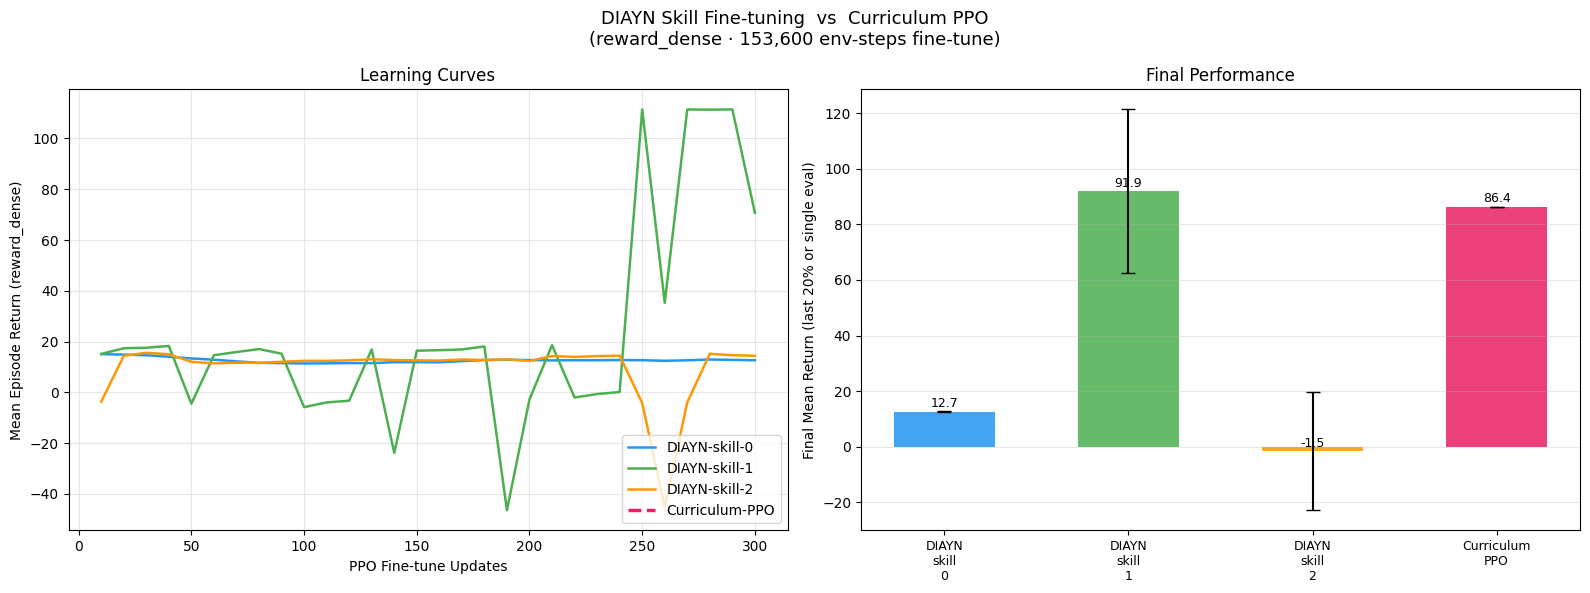

Saved → checkpoints/compare/comparison.png


In [6]:
COLOURS = {
    "DIAYN-skill-0":  "#2196F3",
    "DIAYN-skill-1":  "#4CAF50",
    "DIAYN-skill-2":  "#FF9800",
    "Curriculum-PPO": "#E91E63",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("DIAYN Skill Fine-tuning  vs  Curriculum PPO\n"
             f"(reward_dense · {PPO_CFG['n_steps']*PPO_CFG['n_updates']:,} env-steps fine-tune)",
             fontsize=13)

ax = axes[0]
for label, curve in results.items():
    updates = [c[0] for c in curve]
    returns = [c[1] for c in curve]
    lw = 2.5 if "Curriculum" in label else 1.8
    ls = "--" if "Curriculum" in label else "-"
    ax.plot(updates, returns, color=COLOURS.get(label,"grey"), lw=lw, ls=ls, label=label)
ax.set_xlabel("PPO Fine-tune Updates"); ax.set_ylabel("Mean Episode Return (reward_dense)")
ax.set_title("Learning Curves"); ax.legend(loc="lower right"); ax.grid(alpha=0.3)

ax2 = axes[1]
final_means, final_stds = {}, {}
for label, curve in results.items():
    tail = [c[1] for c in curve[-max(1,len(curve)//5):]]
    final_means[label] = np.mean(tail); final_stds[label] = np.std(tail)

labels = list(final_means.keys())
bars   = ax2.bar(range(len(labels)),
                 [final_means[l] for l in labels],
                 yerr=[final_stds[l] for l in labels],
                 color=[COLOURS.get(l,"grey") for l in labels],
                 alpha=0.85, capsize=5, width=0.55)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels([l.replace("-","\n") for l in labels], fontsize=9)
ax2.set_ylabel("Final Mean Return (last 20% or single eval)")
ax2.set_title("Final Performance"); ax2.grid(axis="y", alpha=0.3)
for bar, m in zip(bars, [final_means[l] for l in labels]):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f"{m:.1f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
out = os.path.join(FINETUNE_DIR, "comparison.png")
plt.savefig(out, dpi=130); plt.show()
print(f"Saved → {out}")

## Summary Table

In [7]:
print(f"\n{'Method':<22} {'Final Return (mean±std)':>26}  {'Best Return':>14}")
print("-"*66)
for label, curve in results.items():
    tail    = [c[1] for c in curve[-max(1,len(curve)//5):]]
    all_ret = [c[1] for c in curve]
    marker  = " ← baseline" if "Curriculum" in label else ""
    print(f"{label:<22}  {np.mean(tail):+8.2f} ± {np.std(tail):5.2f}"
          f"          {max(all_ret):+8.2f}{marker}")

diayn_finals = {k: np.mean([c[1] for c in v[-max(1,len(v)//5):]])
                for k,v in results.items() if "DIAYN" in k}
if diayn_finals:
    best   = max(diayn_finals, key=diayn_finals.get)
    base   = np.mean([c[1] for c in results.get("Curriculum-PPO",[(0,0)])])
    delta  = diayn_finals[best] - base
    print(f"\n→ Best DIAYN skill : {best}")
    print(f"→ vs Curriculum PPO: {delta:+.2f} return difference")
    print("✅ DIAYN pre-training helped!" if delta > 0 else
          "⚠  Curriculum PPO still leads at this fine-tune budget.")


Method                    Final Return (mean±std)     Best Return
------------------------------------------------------------------
DIAYN-skill-0             +12.70 ±  0.16            +15.07
DIAYN-skill-1             +91.94 ± 29.36           +111.42
DIAYN-skill-2              -1.51 ± 21.28            +15.60
Curriculum-PPO            +86.37 ±  0.00            +86.37 ← baseline

→ Best DIAYN skill : DIAYN-skill-1
→ vs Curriculum PPO: +5.57 return difference
✅ DIAYN pre-training helped!
